---
title: "🗓️ Week 02:<br/>Introduction to Regression Algorithms"
subtitle: "Theme: Supervised Learning"
author: "Dr. Ghita Berrada"
format:
  html:
    code-fold: false
    toc: true
    toc-depth: 3
    number-sections: true
    theme: cosmo
execute:
  warning: false
  message: false
jupyter: py313-core
---

In [13]:
# ============================================================
# Imports (good practice: all libraries at the top)
# ============================================================
import sys
import numpy as np
import pandas as pd
import missingno as msno

import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [14]:
# Quick environment check (so you can confirm we're on the right kernel)
print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

Python executable: c:\Users\RobertC\.conda\envs\ds202w2\python.exe
Python version: 3.13.11


# 1. Learning from data: a deliberately simple example

A classic way to understand “learning from data” is to start with a sequence.

Consider:

$$
2,; 4,; 6,; 8,; 10
$$

A very natural “model” is: *add 2 each time*, or (indexing the sequence by position (x = 1,2,3,4,5)):

$$
y = 2x
$$

But here is the first key lesson:

> **Even this tiny dataset can be modelled in multiple ways.**

To see why, we’ll treat the position in the sequence as the predictor (x), and the sequence values as the outcome (y).

In [15]:
# Data: sequence as (x, y)
seq1 = pd.DataFrame({"x": [1,2,3,4,5], "y": [2,4,6,8,10]})
seq2 = pd.DataFrame({"x": [1,2,3,4,5], "y": [2,4,6,8,11]})

## 1.1 Multiple models can fit the *same* data

Here are four *explicit* models that are all plausible candidates for the first sequence:

1. **Linear model** (degree 1 polynomial):
   $$
   \hat{y} = \beta_0 + \beta_1 x
   $$

2. **Quadratic model** (degree 2 polynomial):
   $$
   \hat{y} = a x^2 + b x + c
   $$

3. **Exponential model**:
   $$
   \hat{y} = A \cdot B^x
   $$

4. **Interpolating polynomial** (degree 4 polynomial that fits *exactly* all 5 points):
   $$
   \hat{y} = \gamma_0 + \gamma_1 x + \gamma_2 x^2 + \gamma_3 x^3 + \gamma_4 x^4
   $$

They are different “stories” about the same data.

Let’s fit them and compare their **extrapolations** (what they predict at (x=6)).

In [16]:
def fit_models_on_sequence(df):
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()

    # 1) Linear: degree 1 polynomial
    lin_coef = np.polyfit(x, y, deg=1)   # returns [beta1, beta0]
    lin = np.poly1d(lin_coef)

    # 2) Quadratic: degree 2 polynomial
    quad_coef = np.polyfit(x, y, deg=2)
    quad = np.poly1d(quad_coef)

    # 3) Exponential: y = A * B^x
    # Fit log(y) = log(A) + x*log(B)
    # (requires y > 0, which we have here)
    logy = np.log(y)
    exp_coef = np.polyfit(x, logy, deg=1)     # logy = m*x + c
    m, c = exp_coef[0], exp_coef[1]
    A = np.exp(c)
    B = np.exp(m)

    def exp_model(xvals):
        return A * (B ** xvals)

    # 4) Interpolating polynomial: degree 4 fits 5 points exactly
    interp_coef = np.polyfit(x, y, deg=4)
    interp = np.poly1d(interp_coef)

    return {
        "linear": lin,
        "quadratic": quad,
        "exponential": exp_model,
        "interpolating_poly_deg4": interp,
        "params": {
            "linear": lin_coef,
            "quadratic": quad_coef,
            "exponential": {"A": A, "B": B},
            "interpolating_poly_deg4": interp_coef
        }
    }

models_seq1 = fit_models_on_sequence(seq1)
models_seq2 = fit_models_on_sequence(seq2)

# Compare extrapolation at x=6
x_next = 6
preds_seq1 = {
    "linear": float(models_seq1["linear"](x_next)),
    "quadratic": float(models_seq1["quadratic"](x_next)),
    "exponential": float(models_seq1["exponential"](x_next)),
    "interpolating_deg4": float(models_seq1["interpolating_poly_deg4"](x_next)),
}
preds_seq2 = {
    "linear": float(models_seq2["linear"](x_next)),
    "quadratic": float(models_seq2["quadratic"](x_next)),
    "exponential": float(models_seq2["exponential"](x_next)),
    "interpolating_deg4": float(models_seq2["interpolating_poly_deg4"](x_next)),
}

pd.DataFrame({"seq1_next_pred_at_x6": preds_seq1, "seq2_next_pred_at_x6": preds_seq2})

,seq1_next_pred_at_x6,seq2_next_pred_at_x6
linear,12.000000,12.800000
quadratic,12.000000,13.800000
exponential,16.848345,18.183245
interpolating_deg4,12.000000,17.000000


### Why this matters

* For the *first* sequence, many models fit extremely well and agree on “what comes next”.
* For the *second* sequence, those same models can disagree substantially.

This is the deeper point:

> **Data do not uniquely determine the model.**
> We choose models based on assumptions, goals (prediction vs explanation), and plausibility.

This illustrates a foundational principle in data analysis, famously summarised by George Box:

> “All models are wrong, but some are useful.”

Learning from data is therefore not about discovering a single “true” model, but about choosing a model that is useful for a given purpose.

## 1.2 Visualising: same data, different plausible models

In [17]:
def plot_sequence_with_models(df, models, title):
    x_grid = np.linspace(df["x"].min(), df["x"].max() + 1, 200)

    fig = go.Figure()

    # points
    fig.add_trace(go.Scatter(
        x=df["x"], y=df["y"],
        mode="markers",
        name="Observed data",
        marker=dict(size=10)
    ))

    # fitted curves
    fig.add_trace(go.Scatter(x=x_grid, y=models["linear"](x_grid), mode="lines", name="Linear"))
    fig.add_trace(go.Scatter(x=x_grid, y=models["quadratic"](x_grid), mode="lines", name="Quadratic"))
    fig.add_trace(go.Scatter(x=x_grid, y=models["exponential"](x_grid), mode="lines", name="Exponential"))
    fig.add_trace(go.Scatter(x=x_grid, y=models["interpolating_poly_deg4"](x_grid), mode="lines", name="Interpolating (deg 4)"))

    # show x=6 vertical reference
    fig.add_vline(x=6, line_dash="dash", opacity=0.5)
    fig.update_layout(title=title, xaxis_title="x (position)", yaxis_title="y (value)", legend_title="Model")
    return fig

plot_sequence_with_models(seq1, models_seq1, "Sequence 1: Many models fit well (and may extrapolate similarly)")

In [18]:
plot_sequence_with_models(seq2, models_seq2, "Sequence 2: Small change → models disagree more about extrapolation")

---

# 2. Why modelling is approximation (and why that’s okay)

Real-world data behaves more like the second sequence than the first:

* there is noise,
* relationships are not exact,
* and we never observe everything that matters.

So modelling is not “finding the truth”. It is:

> finding a **useful approximation** to an unknown process.

This is exactly where machine learning (and statistical modelling) becomes valuable.

---

# 3. From rules to learning: why machine learning exists at all

Before machine learning, most automated decision systems were **rule-based**.

This is not a historical accident — it reflects how humans naturally reason about decisions.

Rules take the form:

* *If* income is below £X → *then* eligible for benefit
* *If* credit score < 600 → *then* reject loan
* *If* temperature < 0 → *then* ice risk

Early computer systems simply encoded these rules.

Machine learning did not emerge because rules are *bad*.
It emerged because **there are limits to what rules can realistically capture**.

---

## 3.1 Why rules are attractive — and why they are used

Rules have clear advantages:

* they are **explicit**,
* they are **transparent**,
* they align naturally with legal and policy frameworks,
* they are easy to justify *ex ante*.

From a policymaker’s perspective, rules provide:

* consistency,
* accountability,
* and clear lines of responsibility.

From a claimant’s perspective, however, rules can feel:

* rigid,
* insensitive to context,
* and poorly aligned with lived realities.

This tension matters.

Rules are often **necessary**, but not always **sufficient**.

---

## 3.2 A case where rules work reasonably well

Suppose we want to determine **eligibility for a means-tested benefit**.

The policy specifies:

* income below a fixed threshold,
* savings below a fixed threshold,
* residency and household composition criteria.

Here:

* the outcome is explicitly defined by policy,
* thresholds are normative rather than empirical,
* discretion is intentionally limited.

Rules are doing exactly what they were designed to do.

But even here, cracks can appear:

* irregular income,
* reporting errors,
* atypical household arrangements.

This does *not* mean rules should disappear —
it means we should understand their limits.

---

## 3.3 When rules start to break down

Now consider a different task:

> *Explain or predict unemployment rates across local authorities.*

We might try rules such as:

* “Higher qualifications → lower unemployment”
* “More professional occupations → lower unemployment”
* “Good connectivity → better labour-market outcomes”

Immediately, problems arise:

* How high is “high”?
* Do effects combine linearly or interact?
* What if two rules point in opposite directions?
* What if relationships differ across places?
* What if effects are gradual, not threshold-based?

Rules proliferate, thresholds multiply, and interpretation becomes fragile.

This is not a failure of logic — it is a mismatch between:

* **complex, continuous social processes**
* and **rigid, discrete rule systems**.

---

## 3.4 This motivates machine learning

Machine learning offers a different strategy:

> Instead of writing rules by hand, we **learn patterns from data**.

Given:

* observed characteristics (X),
* observed outcomes (Y),

we estimate how (X) and (Y) are related.

Crucially:

* relationships can be continuous,
* multiple predictors can matter simultaneously,
* performance can be evaluated empirically.

There are several types of machine learning families. The one we're tackling today is supervised learning.

---

# 4. Supervised learning: formalising “learning from examples”

Supervised learning assumes we observe **labelled examples**.

Each observation consists of:

* predictors (X),
* an outcome (Y).

We write:

$$
Y = f(X) + \varepsilon
$$

Where:

* $f(X)$ captures the systematic part of the relationship,
* $\varepsilon$ captures everything else:

  * unobserved factors,
  * measurement error,
  * randomness.

A key point:

* $f$ is unknown,
* different methods correspond to **different assumptions about (f)**.

---

# 5. Regression vs classification (problem types, not algorithms)

Supervised learning problems differ by the **type of outcome**.

## 5.1 Classification

The outcome takes discrete values.

Examples:

* **Loan default**
  *Problem*: Given applicant characteristics, will this loan default?

* **Fraud detection**
  *Problem*: Given transaction features, is this transaction fraudulent?

* **Eligibility**
  *Problem*: Given household circumstances, is this household eligible for a specific benefit?

In each case:

* the task is to assign an observation to a category.

---

## 5.2 Regression

The outcome is continuous.

Examples:

* wages prediction,
* house prices prediction,
* prediction of unemployment rates.

This lecture focuses on **regression**, using unemployment as a running case study — not because unemployment is special, but because it is a familiar and policy-relevant continuous outcome.

---

# 6. Linear regression: the simplest regression model

Linear regression assumes that the **average relationship** between predictors and outcome can be approximated by a linear function.

This makes it:

* conceptually simple,
* mathematically tractable,
* and an excellent entry point into supervised learning.

---

## 6.1 Notation Guide

Throughout this material, we use standard statistical notation:

**The "hat" symbol (^) means estimated or predicted:**

- ŷ = predicted value of y (from our model)
- β̂₀, β̂₁ = estimated coefficients (our best guesses of the true values)
- ê = estimated error/residual

**The "bar" symbol (¯) means sample mean (average):**

- x̄ = sample mean of x = (1/n)Σxᵢ
- ȳ = sample mean of y = (1/n)Σyᵢ

**Greek letters for population parameters (true, unknown values):**

- β₀, β₁ = true intercept and slope (we never know these)
- ε = true error term (unobservable)

**Latin letters for observed data:**

- xᵢ, yᵢ = observed values for observation i
- n = sample size

**The distinction matters:**

- x̄ is just a calculation from our data (the average)
- x̂ would imply we're estimating x, which we don't do
- We estimate β (parameters) and predict y (outcomes), but we simply calculate means

---

## 6.2 Univariate linear regression

With one predictor:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

* $\beta_0$: intercept (baseline level of $Y$)
* $\beta_1$: slope (change in $Y$ per unit change in $X$)

---

## 6.3 Multivariate linear regression

With multiple predictors:

$$
Y = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p + \varepsilon
$$

Each coefficient answers a *conditional* question:

> How does $Y$ change when $X_j$ increases, **holding all other predictors constant**?

This “holding constant” interpretation is powerful but also demanding — it relies on assumptions we must examine.

---

## 6.3 Geometric interpretation

* With one predictor: we fit a **line**.
* With two predictors: a **plane**.
* With many predictors: a **hyperplane**.

Each coefficient controls the **tilt** of this surface along one dimension of the predictor space.

---

# 7. Assumptions of linear regression

Linear regression is simple, but it rests on assumptions.

These assumptions are not technical footnotes —
they determine when interpretation and inference are meaningful.

---

## 7.1 Linearity of the conditional mean

Linearity does **not** mean all points lie on a line.

It means:

> The **expected value of (Y) given (X)** follows a linear pattern.

Individual observations can deviate substantially due to noise.

In [19]:
np.random.seed(1)
x = np.linspace(0, 10, 50)

y_linear = 2 * x + np.random.normal(0, 1, len(x))
y_nonlinear = 2 * x +  x**2 + np.random.normal(0, 5, len(x))

df_shape = pd.DataFrame({
    "x": np.concatenate([x, x]),
    "y": np.concatenate([y_linear, y_nonlinear]),
    "scenario": ["Linear conditional mean"] * len(x) +
                ["Non-linear conditional mean"] * len(x)
})

px.scatter(df_shape, x="x", y="y", facet_col="scenario",
           title="Linearity refers to the conditional mean, not individual points")

---

## 7.2 Independence of errors

Errors should be independent across observations.

Intuitively:

* knowing one error should not help predict another.

Violations occur in:

* time series (serial correlation), where consecutive observations are related because they're close in time - e.g., if unemployment is high today, it's likely high tomorrow,
* clustered data (households, schools, firms), where observations within the same group tend to be more similar to each other than to observations in other groups - e.g., students in the same school share the same teachers and resources, making their outcomes correlated.

When errors are dependent:

* uncertainty is underestimated because correlated observations provide less independent information than the sample size suggests - standard errors become artificially small,
* inference becomes unreliable - we become overconfident in our results, claiming relationships are "statistically significant" when they may not be. For instance, in time series data, we could mistakenly conclude a policy reduced unemployment when the observed decline is simply part of an autocorrelated trend that would have occurred anyway.

---

## 7.3 Homoskedasticity (constant variance)

The spread of errors should be roughly constant across values of $X$.

In [20]:
y_homo = 2 * x + np.random.normal(0, 1, len(x))
y_hetero = 2 * x + np.random.normal(0, x / 2, len(x))

df_var = pd.DataFrame({
    "x": np.concatenate([x, x]),
    "y": np.concatenate([y_homo, y_hetero]),
    "scenario": ["Homoskedastic"] * len(x) +
                ["Heteroskedastic"] * len(x)
})

px.scatter(df_var, x="x", y="y", facet_col="scenario",
           title="Constant vs changing error variance")

---

# 8. Residuals: definition, meaning, and expectations

Once we fit a model, we compute predictions $\hat{y}_i$.

### Definition

$$
\epsilon_i = \text{Residual}_i = y_i - \hat{y}_i
$$

* positive residual → model **under-predicted**
* negative residual → model **over-predicted**

Residuals tell us **what the model failed to explain**.

---

## 8.1 What we expect from residuals in a good model

If linear regression is a reasonable approximation, residuals should:

1. be centred around zero,
2. show no systematic patterns,
3. have roughly constant spread.

These expectations follow directly from the assumptions.

---

## 8.2 Why “centred around zero”

If residuals are mostly positive in some region:

* the model is systematically under-predicting there.

If mostly negative:

* the model is systematically over-predicting.

“Systematic” means:

* errors depend on predictors,
* structure remains unexplained.

A centred residual distribution suggests the model is **correct on average**.

---

## 8.3 Why “no patterns”

Patterns indicate that the model has missed structure:

* curvature → non-linearity,
* trends → omitted variables,
* funnels → heteroskedasticity.

Residual plots are therefore **diagnostic tools**, not cosmetic ones.

---

# 9. Ordinary Least Squares (OLS)

Linear regression specifies the *form* of the model, not how coefficients are estimated.

The most common estimation method is **Ordinary Least Squares (OLS)**.

OLS chooses coefficients that minimise the **Residual Sum of Squares (RSS)**:

$$
RSS = \sum (y_i - \hat{y}_i)^2
$$

---

## 9.1 Why not minimise the sum of residuals?

Because positive and negative errors cancel out, making a bad model appear good.

For example:

* Predict 2% for an area with 10% unemployment → error = -8%
* Predict 10% for an area with 2% unemployment → error = +8%
* Sum of errors = 0 (looks perfect!)

Yet both predictions are wildly wrong. We need a metric that penalises errors regardless of direction - either by taking absolute values |eᵢ| or by squaring them eᵢ². 

**Why square instead of using absolute values?**

Squaring has several advantages:

1. **Mathematical convenience and differentiability**
   
   - Squared functions are smooth and differentiable everywhere - we can use calculus to find the minimum
   - Absolute value |x| has a "kink" at zero where the derivative is undefined, making it impossible to use standard calculus-based optimisation
   - Squaring gives us a closed-form solution (exact formula for β̂) by taking partial derivatives and setting them to zero
   - Minimising |eᵢ| requires iterative numerical methods instead

2. **Penalises large errors more heavily**
   
   - Error of 2: |2| = 2, but 2² = 4
   - Error of 4: |4| = 4, but 4² = 16 (four times worse, not twice!)
   - For unemployment, being off by 5 percentage points is much worse than being off by 1

Note: Minimising absolute errors (Least Absolute Deviations) is used in robust regression when you want to reduce the influence of outliers, but it requires iterative numerical optimisation rather than the simple closed-form OLS solution.

---

# 10. Visual intuition for OLS

In [21]:
from sklearn.linear_model import LinearRegression

np.random.seed(2)
x_demo = np.linspace(0, 10, 60)
y_demo = 3 + 1.5 * x_demo + np.random.normal(0, 2, len(x_demo))

df_demo = pd.DataFrame({"x": x_demo, "y": y_demo})

model = LinearRegression().fit(df_demo[["x"]], df_demo["y"])
df_demo["y_hat"] = model.predict(df_demo[["x"]])
df_demo["resid"] = df_demo["y"] - df_demo["y_hat"]

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_demo["x"], y=df_demo["y"],
                         mode="markers", name="Observed"))
fig.add_trace(go.Scatter(x=df_demo["x"], y=df_demo["y_hat"],
                         mode="lines", name="OLS fit"))

for _, r in df_demo.iloc[::8].iterrows():
    fig.add_trace(go.Scatter(
        x=[r["x"], r["x"]],
        y=[r["y"], r["y_hat"]],
        mode="lines",
        showlegend=False,
        opacity=0.5
    ))

fig.update_layout(title="OLS minimises the sum of squared vertical distances",
                  xaxis_title="X", yaxis_title="Y")
fig.show()

---

## 11. OLS derivation (for reference)

For simple regression:
$$
\text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2
$$

To minimize, we take partial derivatives with respect to each parameter and set them to zero (first-order conditions).

### Finding β̂₀ (the intercept)

Take the partial derivative with respect to β₀:
$$
\frac{\partial \text{RSS}}{\partial \beta_0} = \frac{\partial}{\partial \beta_0}\left[\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2\right]
$$

Apply the chain rule:
$$
= \sum_{i=1}^n 2(y_i - \beta_0 - \beta_1 x_i) \cdot (-1) = -2\sum_{i=1}^n(y_i - \beta_0 - \beta_1 x_i)
$$

Set equal to zero:
$$
-2\sum_{i=1}^n(y_i - \beta_0 - \beta_1 x_i) = 0
$$

Divide by -2:
$$
\sum_{i=1}^n(y_i - \beta_0 - \beta_1 x_i) = 0
$$

Expand the summation:
$$
\sum_{i=1}^n y_i - \sum_{i=1}^n\beta_0 - \sum_{i=1}^n\beta_1 x_i = 0
$$

Simplify (β₀ and β₁ are constants):
$$
\sum_{i=1}^n y_i - n\beta_0 - \beta_1\sum_{i=1}^n x_i = 0
$$

Solve for β₀:
$$
n\beta_0 = \sum_{i=1}^n y_i - \beta_1\sum_{i=1}^n x_i
$$

$$
\beta_0 = \frac{1}{n}\sum_{i=1}^n y_i - \beta_1 \cdot \frac{1}{n}\sum_{i=1}^n x_i
$$

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

**Key insight:** The regression line passes through the point (x̄, ȳ).

### Finding β̂₁ (the slope)

Take the partial derivative with respect to β₁:
$$
\frac{\partial \text{RSS}}{\partial \beta_1} = \frac{\partial}{\partial \beta_1}\left[\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2\right]
$$

Apply the chain rule:
$$
= \sum_{i=1}^n 2(y_i - \beta_0 - \beta_1 x_i) \cdot (-x_i) = -2\sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i)
$$

Set equal to zero:
$$
-2\sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i) = 0
$$

Divide by -2:
$$
\sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i) = 0
$$

Expand:
$$
\sum_{i=1}^n x_i y_i - \beta_0\sum_{i=1}^n x_i - \beta_1\sum_{i=1}^n x_i^2 = 0
$$

Substitute β₀ = ȳ - β₁x̄:
$$
\sum_{i=1}^n x_i y_i - (\bar{y} - \beta_1\bar{x})\sum_{i=1}^n x_i - \beta_1\sum_{i=1}^n x_i^2 = 0
$$

Expand:
$$
\sum_{i=1}^n x_i y_i - \bar{y}\sum_{i=1}^n x_i + \beta_1\bar{x}\sum_{i=1}^n x_i - \beta_1\sum_{i=1}^n x_i^2 = 0
$$

Rearrange to isolate terms with β₁:
$$
\sum_{i=1}^n x_i y_i - \bar{y}\sum_{i=1}^n x_i = \beta_1\left(\sum_{i=1}^n x_i^2 - \bar{x}\sum_{i=1}^n x_i\right)
$$

Now we use two algebraic identities:

**Identity 1 (for the numerator):**
$$
\sum_{i=1}^n x_i y_i - \bar{y}\sum_{i=1}^n x_i = \sum_{i=1}^n x_i y_i - n\bar{x}\bar{y} = \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

**Identity 2 (for the denominator):**
$$
\sum_{i=1}^n x_i^2 - \bar{x}\sum_{i=1}^n x_i = \sum_{i=1}^n x_i^2 - n\bar{x}^2 = \sum_{i=1}^n (x_i - \bar{x})^2
$$

Therefore:
$$
\beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}
$$

This can also be written as:
$$
\hat{\beta}_1 = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}
$$

### Final OLS formulas

$$
\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}
$$

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

**Key insights:**

* The slope β̂₁ is the ratio of covariance to variance
* The intercept β̂₀ ensures the line passes through (x̄, ȳ)
* Both coefficients are entirely data-driven
* This is a closed-form solution - no iterative optimization needed
* The formulas work for any dataset - they're universal

# **12. The Modelling Dataset**

## **12.1 Unit of analysis and time frame**

Our dataset is a **cross-sectional dataset of English local authorities** obtained from merging the ONS^[Office for National Statistics] datasets i.e merged sheets from the [ONS local indicators data](https://www.ons.gov.uk/explore-local-statistics/indicators).

:::callout-note

### 🏡 Takeaway home exercise

As an exercise in data cleaning/wrangling (and to practice your Python/`pandas` skills), you could try and merge the source datasets to try and obtain the merged dataset used in this lecture.

:::

* **Unit of analysis**: Local authority (e.g., Birmingham, Camden, County Durham)
* **Geographical coverage**: England only
* **Time reference**: most of our socio-economic indicators refer to **2019**, the connectivity ones are from 2025

### **Why mixing 2025 and 2019 data is acceptable here**

In cross-sectional analysis, we're asking:

> "What characteristics of local authorities are associated with unemployment **differences between areas**?"

We are **not** asking:

> "How have areas changed over time?"

This distinction is crucial:

**Time-varying vs structural characteristics**

Some variables capture **current conditions** (2019):

- Median pay → reflects recent wage levels
- Business births → captures recent entrepreneurial activity
- Digital infrastructure → measures current connectivity

Other variables capture **structural features** that change slowly:
- Connectivity changes slowly → reflects infrastructure
- We're supposing the values of connectivity in 2025 are sensibly similar to what they were in 2019

**The key criterion**: Does the variable meaningfully differentiate areas in 2019?



---

## **12.2 Initial data exploration**

Before describing individual variables, let's understand the **overall structure and quality** of our data.

Let's load our data:

In [22]:
df = pd.read_csv('../data/ons_local_authority_dataset.csv')

We explicitly examine the **four core dimensions** of data quality:

1. Variable types and structure
2. Missingness extent and patterns
3. Correlation structure
4. Distribution shape (skewness)

---

### **Dataset structure and variable types**

#### **Basic structure check**

In [23]:
print(f"Dataset shape: {df.shape[0]} areas × {df.shape[1]} variables")
print(f"\nVariable types:")
print(df.dtypes.value_counts())

Dataset shape: 471 areas × 20 variables

Variable types:
float64    18
object      2
Name: count, dtype: int64


Before plotting anything, we inspect the *shape* and *types* of the data.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Area code                   471 non-null    object 
 1   population_density          413 non-null    float64
 2   pct_age_16_64               413 non-null    float64
 3   modelled_unemployment_rate  371 non-null    float64
 4   gdhi_per_head               412 non-null    float64
 5   median_weekly_pay           391 non-null    float64
 6   inward_fdi                  25 non-null     float64
 7   active_businesses           448 non-null    float64
 8   business_births             448 non-null    float64
 9   business_deaths             448 non-null    float64
 10  high_growth_businesses      448 non-null    float64
 11  cancer_stage1_2             265 non-null    float64
 12  gigabit_broadband           415 non-null    float64
 13  coverage_4g                 415 non

**What this tells us**

* Number of observations (local authorities)
* Which variables are:

  * floating-point (continuous),
  * integers,
  * or missing-heavy
* Memory usage (not critical here, but good practice)

**Key observations**

* All predictors are numeric → no encoding required
* Outcome variable is continuous → regression is appropriate
* Missing values are unevenly distributed across variables

This confirms:

> The dataset is suitable for regression modelling, but missing data must be handled explicitly.

The two pieces of code above show us that most of the variables are numeric (the only tow exceptions are `Area code` and `Area name` which won't be used for modeling). It also tells us that many variables have missing values (missingness varies by variable - see next section for the nature of that missingness).

In [31]:
print(f"\nBasic summary:")
print(df.describe().T)


Basic summary:
                            count           mean            std           min  \
population_density          413.0    1496.743341    2331.685914      9.000000   
pct_age_16_64               413.0      62.061550       3.747285     52.550000   
modelled_unemployment_rate  371.0       3.695957       1.173311      1.700000   
gdhi_per_head               412.0   21525.230583   10414.923959  13536.000000   
median_weekly_pay           391.0     481.986445      67.547570    358.600000   
inward_fdi                   25.0  186269.080000  416792.278837   5863.000000   
active_businesses           448.0   41681.986607  259768.718714    170.000000   
business_births             448.0      11.819178       3.072290      5.555556   
business_deaths             448.0      10.144109       1.853508      6.091772   
high_growth_businesses      448.0       4.208241       1.119298      0.000000   
cancer_stage1_2             265.0      54.706436       3.567489     45.179060   
gigabit_broa

**Key observations:**

- Variables operate on very different scales (needs attention)
- Many variables are bounded (percentages: 0-100%)

**Why this matters:**

Understanding data structure **before** modelling prevents:

- Misinterpreting coefficients (scale issues)
- Ignoring missingness patterns (bias)
- Missing multicollinearity (unstable estimates)

---

### ** Outcome variable: Modelled unemployment rate (aged 16–64)**

* **Source**: Office for National Statistics (ONS)
* **Type**: Continuous (percentage)
* **Definition**: Model-based estimate of the unemployment rate among working-age individuals (16-64)

**Why "modelled" unemployment?**

ONS produces two unemployment measures:

1. **Survey-based estimates** (from Annual Population Survey)
   
   - Direct survey responses
   - But: High sampling error in small areas
   - Often suppressed for reliability

2. **Model-based estimates** (what we use)
   
   - Combines survey data with administrative data
   - Uses statistical models to reduce noise
   - Available for ALL local authorities
   - More stable over time

**Why this outcome variable?**

✓ **Complete coverage** - available for all English local authorities
✓ **Reduced noise** - smooths survey sampling variability
✓ **Standard measure** - widely used in regional labour market analysis
✓ **Comparable** - consistent definition across areas
✓ **Policy-relevant** - directly interpretable (% unemployed)

**What unemployment rate means:**

Percentage of economically active people (working or seeking work) who are unemployed.

Not included:

- Economically inactive (students, retirees, long-term sick)
- Underemployed (working fewer hours than desired)

This matters for interpretation:

- A 5% unemployment rate means 95% of job-seekers have jobs
- It doesn't capture discouraged workers who stopped looking
- Different from employment rate (which includes inactive people)

---

### **Predictor variables**

The predictors fall into **six conceptual groups**.

**Why grouping matters:**

1. **For understanding**: Related variables measure similar constructs
2. **For multicollinearity**: Variables within groups often correlate highly
3. **For interpretation**: Coefficients make sense in context
4. **For regularisation**: We can justify why some variables might be redundant

Later we will:
- Assess multicollinearity within and across groups
- Interpret coefficients in their conceptual context
- Use regularisation to handle redundancy

---

#### **1. Demographic structure**

These capture the **size and composition** of the local population.

| Variable             | Description              | Why it matters for unemployment                                    |
| -------------------- | ------------------------ | ------------------------------------------------------------------ |
| `population_density` | People per km²           | Dense areas → thicker labour markets, more job matching, economies of scale |
| `pct_age_16_64`      | % working-age population | Higher % → larger labour supply relative to dependents                      |

**Conceptual logic:**

- **Population density** is a proxy for urbanisation and agglomeration
  - Cities have more diverse job opportunities
  - Better matching between workers and firms
  - But also potentially more competition
  - Effect on unemployment is theoretically ambiguous

- **Working-age share** affects labour market tightness
  - Areas with more retirees → fewer workers per job
  - Areas with more children → more caregiving constraints
  - Directly related to labour force participation

---

#### **2. Labour market & income**

These measure **economic prosperity** and **job quality**.

| Variable                     | Description                           | Why it matters                                |
| ---------------------------- | ------------------------------------- | --------------------------------------------- |
| `median_weekly_pay`          | Median gross weekly earnings (£)      | High pay → better jobs, may attract workers or reflect skills |
| `gdhi_per_head`              | Gross Disposable Household Income (£) | Purchasing power, economic vitality          |
| `modelled_unemployment_rate` | Outcome variable                      | What we're trying to predict                 |

**Conceptual logic:**

- **Median pay** could relate to unemployment in multiple ways:
  
  - High pay areas might have LOW unemployment (strong economy)
  - Or HIGH unemployment (high wages → workers price themselves out)
  - We'll see which pattern dominates in the data

- **Disposable income** measures actual living standards
  
  - Includes transfers, taxes
  - Reflects both wages and government support
  - Might be LOW in high-unemployment areas (less income)
  - Or HIGH (more benefits)

This is why we **don't assume** directions - we let data speak.

---

#### **3. Business dynamics**

These capture **entrepreneurship** and **economic churn**.

| Variable                 | Description                  | Why it matters                              |
| ------------------------ | ---------------------------- | ------------------------------------------- |
| `active_businesses`      | Number of active enterprises | More businesses → more job creation capacity |
| `business_births`        | Business birth rate (%)      | Entrepreneurial dynamism, new opportunities |
| `business_deaths`        | Business death rate (%)      | Economic fragility, job destruction         |
| `high_growth_businesses` | % high-growth firms          | Innovation hubs, scaling companies          |

**Conceptual logic:**

- **Active businesses**: More firms → potentially more jobs
  
  - But size matters too (not captured here)
  - 100 small businesses ≠ 1 large factory

- **Business births**: New firms create jobs
  
  - But also: might reflect desperation (unemployment → self-employment)
  - Correlation with unemployment is empirically unclear

- **Business deaths**: Job destruction
  
  - High churn could mean creative destruction (good)
  - Or economic distress (bad)

- **High-growth firms**: Engines of job creation
  
  - Fast-growing companies create disproportionate employment
  - Usually in innovation sectors

---

#### **4. Health**

| Variable          | Description             | Why it matters                                          |
| ----------------- | ----------------------- | ------------------------------------------------------- |
| `cancer_stage1_2` | % early-stage diagnoses | Proxy for healthcare access, socioeconomic conditions |

**Why include a health indicator?**

This is **not** about cancer per se.

It's a **structural indicator** of:

1. **Healthcare access**
   
   - Early diagnosis requires regular screening
   - Screening participation correlates with:
     - Health literacy
     - Access to GP services
     - Socioeconomic status

2. **Preventative care infrastructure**
   
   - Areas with good preventative care likely have:
     - Better overall services
     - More engaged populations
     - Different employment patterns

3. **Social disadvantage**
   
   - Late diagnosis clusters in deprived areas
   - Reflects multiple disadvantages
   - These same areas often have higher unemployment

**We treat this as a socioeconomic marker, not a health outcome.**

---

#### **5. Digital infrastructure**

These measure **connectivity** and **digital inclusion**.

| Variable                | Description                | Why it matters in modern economy                    |
| ----------------------- | -------------------------- | --------------------------------------------------- |
| `gigabit_broadband`     | % gigabit-capable premises | Remote work feasibility, digital jobs               |
| `coverage_4g`           | % premises with 4G         | Mobile connectivity, gig economy participation      |
| `coverage_5g`           | % premises with 5G         | Cutting-edge connectivity, future-proofing          |
| `premises_below_30mbps` | % low-speed premises       | Digital exclusion, remote work impossible           |

**Conceptual logic:**

**Why digital infrastructure matters for unemployment:**

1. **Remote work opportunities**
   
   - Post-COVID, many jobs can be done remotely
   - Poor connectivity → excluded from these jobs
   - "Work from anywhere" requires fast internet

2. **Job search**
   
   - Most applications are online
   - Video interviews require bandwidth
   - Poor connectivity → harder to find work

3. **Digital divide**
   
   - Low-speed areas often rural
   - Already disadvantaged in labour markets
   - Connectivity compounds existing inequality

4. **Business location**
   
   - Firms requiring connectivity avoid poor areas
   - Self-reinforcing: no infrastructure → no jobs → no investment

**Expected relationships:**

- Good connectivity → LOWER unemployment
- But: could also be reverse causation (prosperous areas invest more)

---

#### **6. Accessibility**

These measure **physical access to jobs**.

| Variable              | Description                        | Why it matters                                      |
| --------------------- | ---------------------------------- | --------------------------------------------------- |
| `travel_time_bike`    | Avg. travel time to jobs (minutes) | Active travel access, urban form                    |
| `travel_time_car`     | Avg. travel time to jobs (minutes) | Car dependence, suburban/rural access               |
| `travel_time_pt_walk` | Public transport & walking (mins)  | Non-car access, equity (not everyone has cars)      |

**Conceptual logic:**

**Spatial mismatch theory:**

- Jobs might be geographically separated from workers
- If commuting is too difficult → unemployed even if jobs exist
- This is NOT about laziness - it's about:
  
  - Can't afford car
  - No public transport
  - Caring responsibilities limit commute time
  - Health conditions prevent long travel

**Different modes capture different constraints:**

- **Cycling time**: urban density, proximity to jobs
- **Car time**: relevant for those with cars (most people)
- **Public transport**: crucial for equity
  - Low-income workers less likely to have cars
  - PT access is a social justice issue

**Expected relationships:**

- Longer travel times → HIGHER unemployment
- But: direction of causation unclear
  - Poor areas → less investment in transport
  - Or: poor transport → economic decline

---

### Missingness percentage by variable**

We quantify *how much* data is missing per variable.

In [26]:
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct

inward_fdi                    94.692144
cancer_stage1_2               43.736730
travel_time_car               22.929936
travel_time_pt_walk           22.929936
travel_time_bike              22.929936
modelled_unemployment_rate    21.231423
median_weekly_pay             16.985138
gdhi_per_head                 12.526539
population_density            12.314225
pct_age_16_64                 12.314225
Area name                     12.314225
premises_below_30mbps         11.889597
coverage_4g                   11.889597
coverage_5g                   11.889597
gigabit_broadband             11.889597
high_growth_businesses         4.883227
business_births                4.883227
business_deaths                4.883227
active_businesses              4.883227
Area code                      0.000000
dtype: float64

**How to read this table**

* Values represent **percentage of local authorities** with missing data
* A value of 0 → fully observed
* Higher values → more severe data loss

**What we typically observe**

* Some variables are almost complete (e.g. unemployment rate)
* Others have substantial missingness (e.g. infrastructure, accessibility)
* Missingness is **variable-specific**, not uniform

This already tells us:

> Dropping rows would disproportionately remove areas missing certain *types* of data.

---

### **Missingness structure (missingno matrix)**

Percentages alone don’t tell us **whether missingness is random**.
For that, we need structure.

<Axes: >

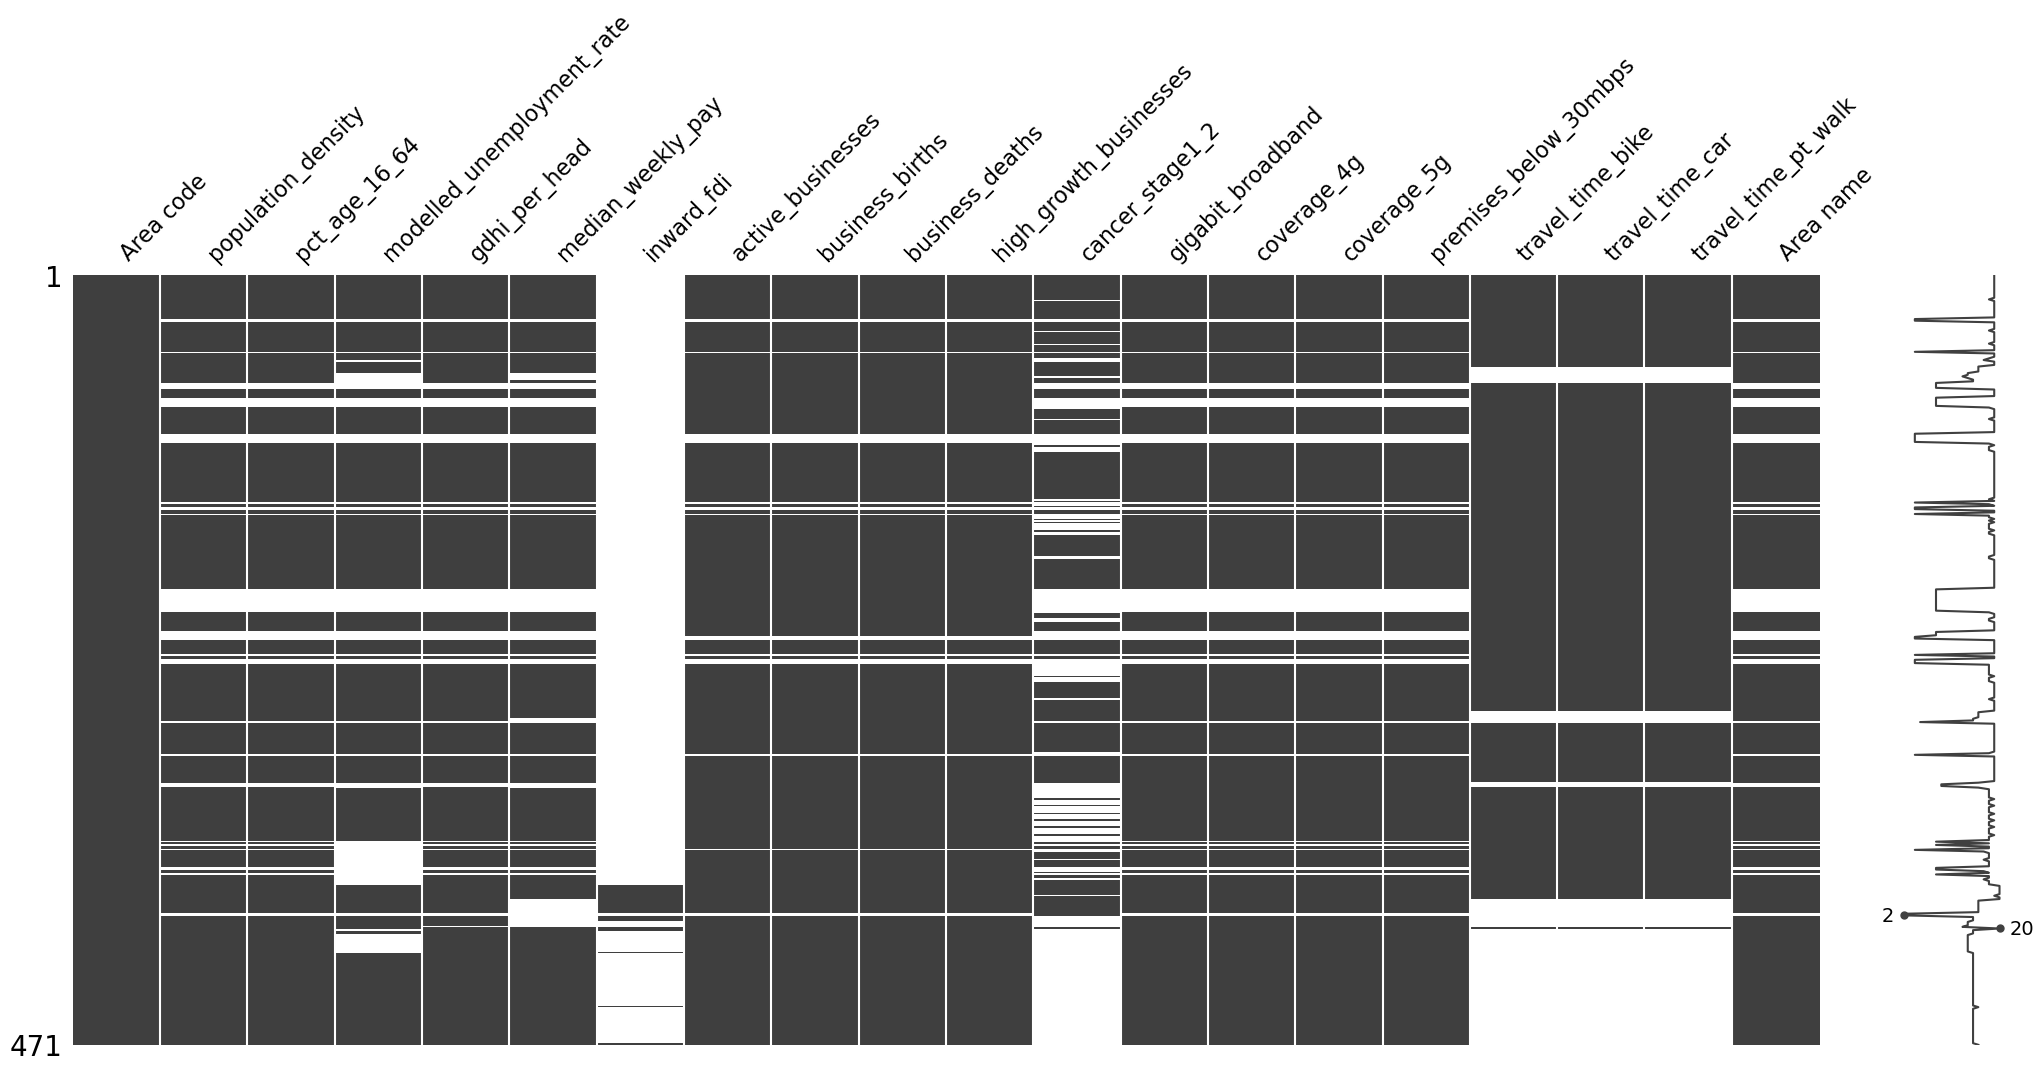

In [27]:
msno.matrix(df)

**How to interpret the matrix**

* Each row → a local authority
* Each column → a variable
* White → observed
* Black → missing

**What we look for**

* Vertical bands → variable-level missingness
* Horizontal blocks → area-level clustering
* Repeating patterns → systematic processes

**What we see in this dataset**

* Clear vertical structure: some variables missing more than others
* Clustering across conceptually related variables
* No random “salt-and-pepper” pattern

This rules out MCAR.

---


### **Interpreting missingness mechanisms**

Visualising missingness is only the first step.
The crucial question is **why values are missing**, because different missingness mechanisms imply **different modelling risks** and **different valid imputation strategies**.

Statistically, we distinguish three mechanisms:

1. **MCAR** – Missing Completely At Random
2. **MAR** – Missing At Random
3. **MNAR** – Missing Not At Random

Understanding these is essential for:

* choosing an imputation strategy,
* avoiding bias,
* and recognising when modelling assumptions break down.

---

#### **MCAR – Missing Completely At Random**

**Definition**

Data are **MCAR** if the probability that a value is missing is **independent of**:

* the variable itself, **and**
* all other observed variables.

Formally:
$$
P(\text{missing} \mid X, Y) = P(\text{missing})
$$

---

**Intuition**

MCAR means *pure randomness*.

Think of:

* a server crash,
* accidental deletion,
* a survey page failing to load for a random subset of respondents.

Missingness has **no structure**, no pattern, no bias.

---

**What MCAR would look like in our data**

If missingness were MCAR, we would expect:

* Random black dots scattered across the missingno matrix
* No vertical bands
* No clustering across related variables
* No correlation between missingness and geography, infrastructure, or deprivation

In practice:

* One local authority missing pay,
* another missing broadband,
* another missing travel times,
* with no overlap or pattern.

---

**Is our data MCAR?**

**No. Clearly not.**

The missingno matrix shows:

* vertical structure (some variables missing much more than others),
* co-missing patterns across conceptually related variables.

That immediately rules out MCAR.

---

**Why MCAR matters (but is rare)**

If data *were* MCAR:

* Dropping rows would not bias estimates
* Mean/median imputation would be relatively harmless
* Standard regression assumptions would hold

But MCAR is **extremely rare** in social science data.

---

#### **MAR – Missing At Random**

**Definition**

Data are **MAR** if missingness depends on **observed variables**,
but **not on the missing value itself**, once those variables are accounted for.

Formally:
$$
P(\text{missing} \mid X, Y) = P(\text{missing} \mid X)
$$
where:

* $Y$ is the variable with missing values,
* $X$ are other observed variables.

---

**Intuition**

MAR means:

> “Values are missing for *systematic reasons*, but those reasons are *visible in the data*.”

Missingness is not random — but it is *explainable*.

---

##### **Concrete MAR examples from our dataset**

**Example 1: Digital infrastructure variables**

Variables like:

* `gigabit_broadband`
* `coverage_5g`
* `premises_below_30mbps`

are more often missing in:

* rural local authorities,
* sparsely populated areas,
* places with limited reporting infrastructure.

Crucially:

* We *observe* population density.
* We *observe* rural–urban differences.
* Missingness depends on these observed features.

So:

> Broadband data are missing **because of geography**, not because broadband values themselves are “too low” to be reported.

That is MAR.

---

**Example 2: Accessibility measures**

Travel-time variables co-miss:

* `travel_time_bike`
* `travel_time_car`
* `travel_time_pt_walk`

Why?

* Some local authorities lack detailed transport modelling
* Rural areas often have less granular transport datasets
* Data availability depends on observed spatial characteristics

Again:

* Missingness is linked to *observable* features
* Not to the (unobserved) travel time itself

---

**Example 3: Health indicators**

The health variable:

* `cancer_stage1_2`

is missing more often in:

* small population areas,
* places where case counts are low,
* areas where disclosure control suppresses statistics.

Importantly:

* Suppression depends on population size (observed)
* Not on whether cancer outcomes are “good” or “bad”

This is classic MAR via disclosure control.

---

##### **Why MAR is the most realistic assumption here**

The missingno heatmap shows:

* strong correlations between missingness indicators
* alignment with conceptual variable groups

This tells us:

> Missingness follows data production processes, not outcome values.

That is exactly what MAR describes.

---

##### **Why MAR matters for modelling**

Under MAR:

* Dropping rows **can bias results**
* Mean/median imputation can distort distributions
* But **model-based imputation is valid**

This justifies:

* KNN imputation
* tree-based imputation
* multiple imputation

**Provided** we do it correctly (see Section 14: leakage).

---

#### **MNAR – Missing Not At Random**

**Definition**

Data are **MNAR** if missingness depends on the **unobserved value itself**, even after conditioning on all observed variables.

Formally:
[
P(\text{missing} \mid X, Y) \text{ depends on } Y
]

---

**Intuition**

MNAR means:

> “Values are missing *because of what they are*.”

This is the most dangerous case.

---

**Classic MNAR examples (not hypothetical)**

* High earners refusing to report income
* Firms not reporting layoffs when numbers are large
* Authorities suppressing indicators because they look bad
* People with poor health opting out of health surveys

In all cases:

* Missingness is *informative*
* The act of being missing carries information

---

**Is our data MNAR?**

We **cannot prove it is not**, but:

* The missingness patterns align with **structural features**
* Missingness clusters across *variables*, not *extreme values*
* Suppression rules are documented and mechanical

There is **no strong evidence** that:

* high unemployment areas systematically hide values,
* or that extreme values are selectively missing.

So MNAR is **possible in theory**, but **not strongly supported by evidence** here.

---

**Why MNAR is problematic**

If data are MNAR:

* No imputation method can fully fix the bias
* Results must be interpreted with caution
* Sensitivity analysis is required

This is why:

> We always explain missingness assumptions explicitly.

---

#### **Conclusion: Which mechanism applies here?**

Based on:

* missingness percentages,
* matrix structure,
* co-missing patterns,
* domain knowledge of ONS data production,

we conclude:

> **The dominant missingness mechanism in this dataset is MAR.**

This directly motivates:

* avoiding row deletion,
* avoiding mean/median imputation,
* using distance- or model-based imputation,
* performing imputation *after* train–test split.

This is not a technical footnote — it shapes the entire modelling pipeline that follows.


---

### **Co-missing patterns (missingness correlation)**

We now check whether variables tend to be missing **together**.

<Axes: >

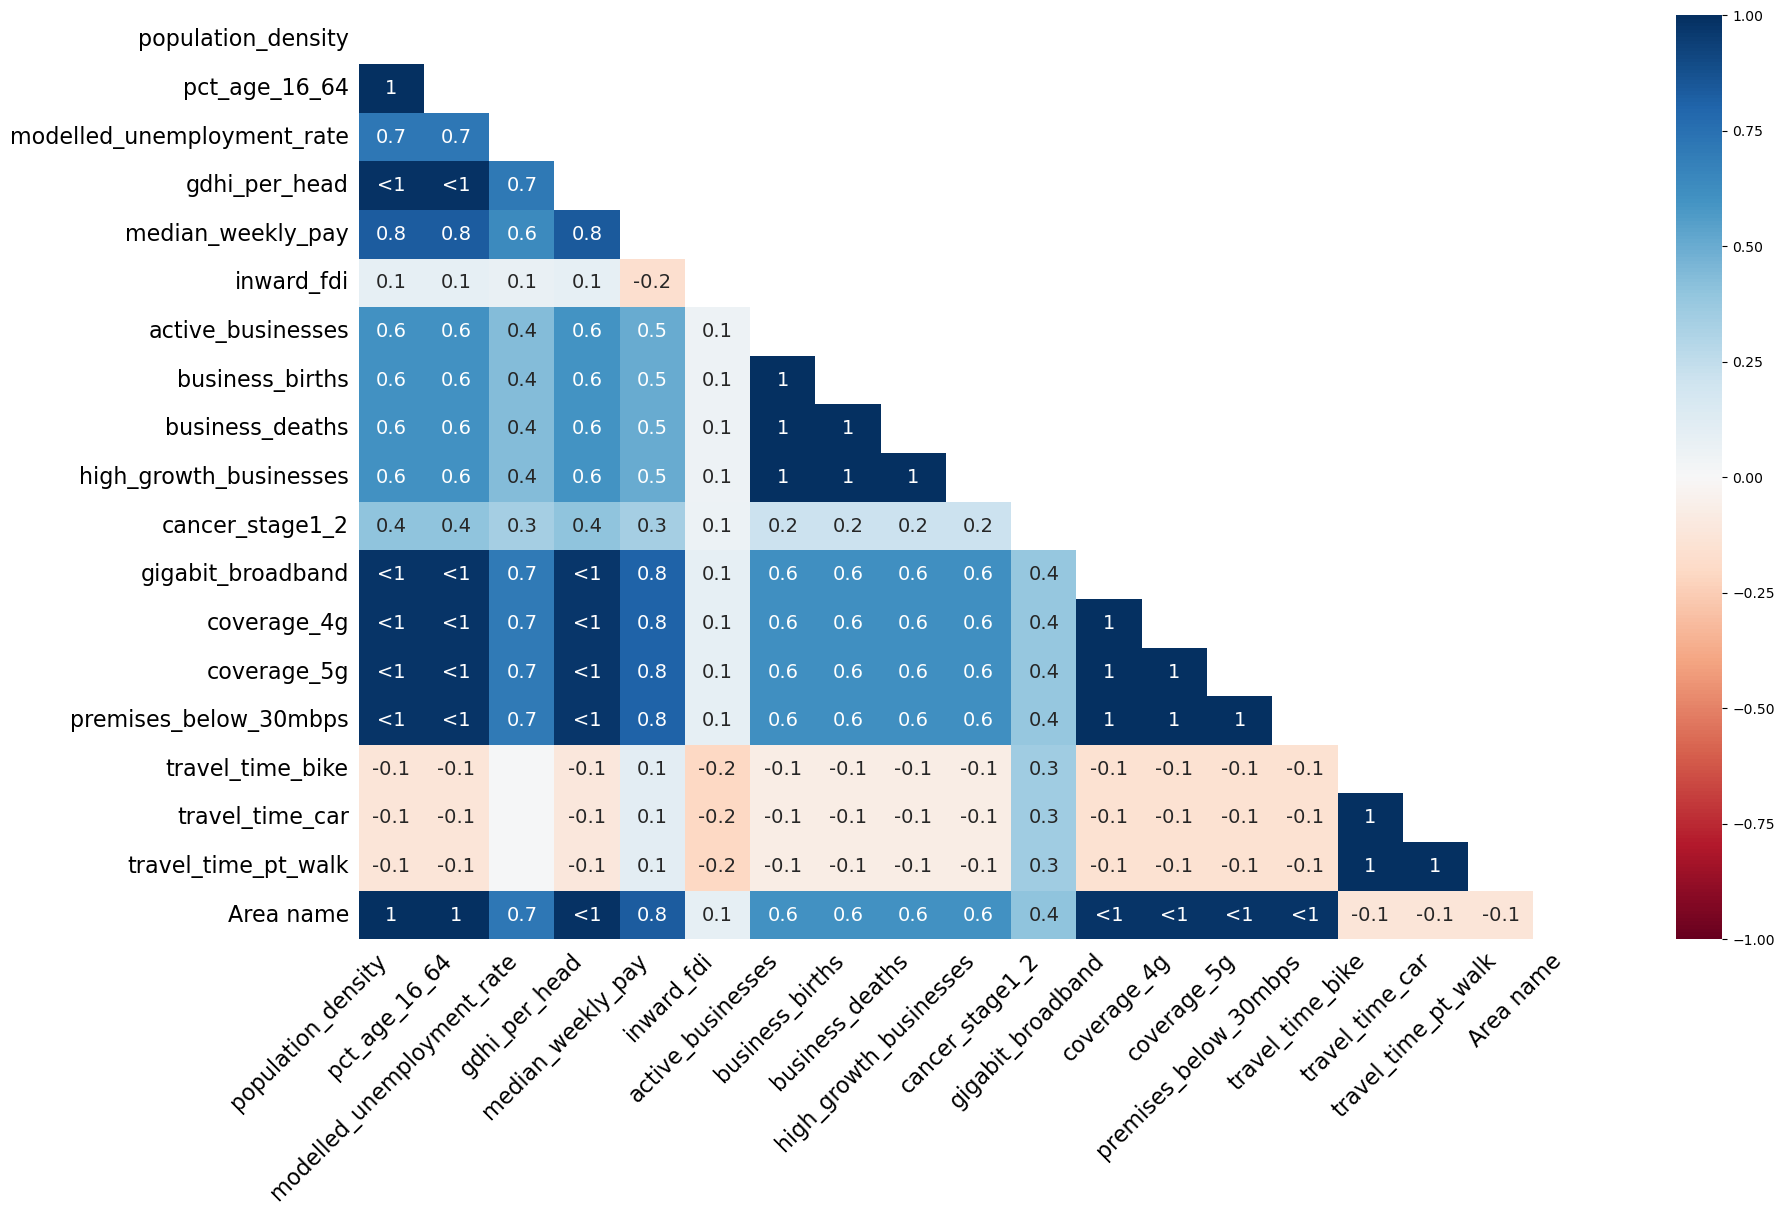

In [28]:
msno.heatmap(df)

**How to read the heatmap**

* Values near +1:

  * variables are often missing at the same time
* Values near 0:

  * missingness is unrelated
  
* Values near –1:

  * rare in practice, but would indicate substitution patterns

**Interpretation**

The missingness heatmap shows **clear structure**, not random gaps.

*Key things to notice:*

1. **Missingness clusters by variable, not randomly by cell**

   * Entire *columns* (e.g. `inward_fdi`, travel-time variables, `cancer_stage1_2`) show substantial missingness.
   * This tells us missingness is driven by **how the data are produced**, not by random recording errors.

2. **Related variables are missing together**

   * `travel_time_bike`, `travel_time_car`, and `travel_time_pt_walk` have *identical missingness patterns*.
   * This strongly suggests these variables come from the **same modelling pipeline** (transport accessibility modelling).
   * If one is missing for an area, the others are missing too.

3. **Row-wise blocks indicate area-level structure**

   * Some local authorities are missing *multiple variables at once*.
   * These are typically:

     * Rural areas
     * Small population authorities
     * Areas where certain indicators are not modelled or suppressed
   * Missingness is therefore **systematic across areas**, not idiosyncratic.

4. **Core economic variables are largely complete**

   * Business dynamics (`active_businesses`, `business_births`, `business_deaths`) show very little missingness.
   * These are administrative datasets with broad coverage.
   * This gives us a relatively stable core set of predictors.

5. **No evidence of completely random missingness**

   * We do *not* see:

     * Isolated single-cell gaps
     * Random scatter across rows and columns
   * This rules out “missing completely at random” as a plausible description.

*What this tells us, in plain terms*

* Missingness is **systematic and explainable**. That is textbook **MAR** behaviour.
* It reflects **data availability and measurement choices**, not data corruption
* Dropping rows with missing values would disproportionately remove:

  * Rural authorities
  * Smaller local economies
* Any modelling approach must therefore **explicitly handle missing data**

This heatmap justifies:

* Avoiding listwise deletion
* Treating missingness as a structural feature of the dataset, not a nuisance

---


### **Correlation matrix (multicollinearity check)**

Before modelling, we need to understand how predictors relate to each other.

In [29]:
corr = df.drop(columns=['Area name','Area code']).corr()

corr

,population_density,pct_age_16_64,modelled_unemployment_rate,gdhi_per_head,median_weekly_pay,inward_fdi,active_businesses,business_births,business_deaths,high_growth_businesses,cancer_stage1_2,gigabit_broadband,coverage_4g,coverage_5g,premises_below_30mbps,travel_time_bike,travel_time_car,travel_time_pt_walk
population_density,1.000000,0.757177,0.392488,0.261695,0.454399,0.106400,-0.040995,0.439926,0.321865,0.229715,-0.054372,0.352968,0.216429,0.375363,-0.281152,-0.487795,-0.271430,-0.594459
pct_age_16_64,0.757177,1.000000,0.337716,0.323574,0.440486,0.243894,0.042568,0.436894,0.318599,0.349728,-0.006853,0.443868,0.144525,0.391303,-0.321110,-0.544728,-0.307266,-0.634244
modelled_unemployment_rate,0.392488,0.337716,1.000000,-0.296692,-0.256226,-0.097453,0.032651,0.463987,0.403570,-0.070817,-0.319323,0.392496,0.091269,0.262994,-0.315288,-0.366178,-0.365513,-0.415336
gdhi_per_head,0.261695,0.323574,-0.296692,1.000000,0.759873,0.441704,0.005108,-0.001775,0.005164,0.244611,0.546214,-0.035585,0.077143,0.072406,0.151843,-0.121980,-0.057275,-0.160798
median_weekly_pay,0.454399,0.440486,-0.256226,0.759873,1.000000,0.387365,0.012000,0.127122,0.103440,0.301742,0.416067,0.178694,0.169451,0.239259,-0.184373,-0.334750,-0.199319,-0.369951
inward_fdi,0.106400,0.243894,-0.097453,0.441704,0.387365,1.000000,0.981048,0.125452,0.055067,0.273308,0.122190,-0.111641,-0.103729,-0.127360,-0.008779,-0.471650,-0.464985,-0.482594
active_businesses,-0.040995,0.042568,0.032651,0.005108,0.012000,0.981048,1.000000,0.039317,0.031229,0.039278,0.012041,0.026274,-0.111301,-0.105628,-0.018071,-0.037740,-0.024818,-0.041992
business_births,0.439926,0.436894,0.463987,-0.001775,0.127122,0.125452,0.039317,1.000000,0.460502,0.105512,-0.039767,0.449075,0.232442,0.405165,-0.402672,-0.411164,-0.240330,-0.447148
business_deaths,0.321865,0.318599,0.403570,0.005164,0.103440,0.055067,0.031229,0.460502,1.000000,0.006309,-0.097679,0.356371,0.184475,0.347565,-0.322850,-0.345758,-0.202459,-0.386094
high_growth_businesses,0.229715,0.349728,-0.070817,0.244611,0.301742,0.273308,0.039278,0.105512,0.006309,1.000000,0.127228,0.184122,0.112413,0.214006,-0.102029,-0.279055,-0.269027,-0.248808


For readability in notebooks:

In [32]:
corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

AttributeError: The '.style' accessor requires jinja2

**What we examine**

* Strong positive correlations → possible redundancy
* Strong negative correlations → opposing mechanisms
* Clusters of correlated variables → conceptual groupings

**Key observations**

* Digital infrastructure variables are mildly correlated
* Business indicators cluster together

This matters because:

* Multicollinearity inflates standard errors
* Coefficients become unstable
* Regularisation may be needed later

---

### **Distribution shape and skewness**

Linear regression does **not** require normal predictors,
but skewed variables can:

* dominate distance-based methods,
* distort regularisation paths,
* complicate interpretation.

We therefore examine skewness numerically.

In [ ]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

skewness

**How to interpret skewness**

* ≈ 0 → roughly symmetric
* > 1 → right-skewed
* < –1 → left-skewed

**What we typically find**

* Income variables → right-skewed
* Business counts → right-skewed
* Travel-related variables are right-skewed
* Connectivity-related variables are left-skewed

This immediately signals:

> Feature scaling and careful interpretation are required, especially for regularised models.

---

## **Summary of EDA findings**

From this structured EDA, we conclude:

1. The dataset is **fully numeric (in the predictors) and regression-ready**
2. Missingness is **systematic (MAR)**, not random
3. Mean/median imputation would distort distributions
4. Several predictors are **highly correlated**
5. Variables operate on **very different scales**
6. Regularisation and proper preprocessing will be essential

This motivates the modelling pipeline used in Sections 13–17.

---

# **13. Preparing for Modelling**

Before fitting any model, we need to be clear about **what problem we are solving**.

We are not trying to perfectly explain unemployment.
We are asking:

> *How well can a set of area-level characteristics predict unemployment in unseen local authorities?*

This framing immediately implies:

* A separation between **training** and **evaluation**
* A concern for **generalisation**
* A modelling pipeline, not a single regression

---

## **13.1 Outcome and predictors**

* **Outcome**: `modelled_unemployment_rate`
* **Predictors**: all remaining numeric variables
* **Excluded**: identifiers (`Area code`, `Area name`)

In [33]:
df_model = df.dropna(subset=["modelled_unemployment_rate"]).copy() # we drop missing values from the outcome variable

X = df_model.drop(columns=["modelled_unemployment_rate", "Area code", "Area name", "inward_fdi"]) #too many missing values in inward_fdi
y = df_model["modelled_unemployment_rate"]

We drop missing values in the outcome.

**Why? And why not impute it?**

When we impute predictors, we are saying:

> “Given other observed variables, we can make a reasonable guess.”

When we impute the outcome, we are saying:

> “We invent the value we are trying to predict.”

This breaks the logic of supervised learning.

*What goes wrong if we impute $y$*

If we impute unemployment:

- The model is trained on fabricated labels

- Evaluation metrics are no longer meaningful

- We artificially inflate performance

- We introduce circularity (the predictors help create the target)

This is fundamentally different from predictor imputation.

---

# **14. Train–Test Split, Generalisation, and Leakage**

## **14.1 Why we split the data**

A model can always fit the data it has already seen.

What we care about is something harder:

> *Will this model work on data it has never seen before?*

This ability is called **generalisation**.

To approximate this:

* We **train** the model on part of the data
* We **evaluate** it on held-out data

---

## **14.2 The train–test split**

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

**Interpretation:**

* 75% of local authorities are used to *learn* relationships
* 25% are treated as *future, unseen areas*
* The random seed ensures reproducibility (i.e no matter how many times we run this code, we get the same result each time)

---

## **14.3 Data leakage (conceptual, not optional)**

**Data leakage** occurs when information from the test set influences the training process.

This can happen even without obvious mistakes.

### **Examples of leakage**

* Scaling before splitting
* Imputing missing values on the full dataset
* Selecting features using all observations
* Tuning hyperparameters using test performance

### **Why leakage is dangerous**

* Test performance becomes artificially high
* The model appears better than it is
* Real-world performance will be worse

> Leakage means the model has seen the exam questions during revision.

---

# **15. Imputation and Scaling (After the Split)**

Even though missingness is already addressed conceptually, **how we implement it still matters**.

---

## **15.1 KNN imputation (applied correctly)**

Yes — this is exactly the right place to pause and explain **KNN imputation properly**, at an *intuition* level, and to be very explicit about **when scaling happens** (this matters a lot and students often get it wrong).

Below is a **drop-in section** you can insert right after the train/test split and before model fitting.

---

# **KNN Imputation: Intuition and Best Practice**

## **Why we need imputation at all**

After removing observations with missing outcomes, our dataset still contains **missing values in the predictors** (income, infrastructure, health, accessibility, etc.).

Linear regression and regularised models **cannot handle missing values**, so we must impute them before fitting models.

The key question is **how**.

---

## **Why not mean or median imputation (for this dataset)?**

A simple approach would be to replace missing values with:

* The mean (or median) of the variable

While this is easy, it has important drawbacks:

1. **It distorts distributions**

   * All missing values collapse to a single number
   * Variance is artificially reduced

2. **It ignores relationships between variables**

   * Income, infrastructure, health, and accessibility are correlated
   * Mean imputation treats variables as independent

3. **It weakens multivariate structure**

   * Which matters especially for regression and regularisation

For exploratory or quick analysis this may be acceptable — but for modelling, we can do better.

---

## **KNN imputation: the core idea (intuition)**

**K-Nearest Neighbours (KNN) imputation** works by exploiting **similarity between observations**.

The intuition is simple:

> “If two local authorities look similar on most variables, they probably have similar values on the missing one.”

### **How it works conceptually**

For a given missing value:

1. Look at all **other local authorities**
2. Measure how similar they are **using the observed variables**
3. Identify the **K most similar areas**
4. Impute the missing value using:

   * The average of those neighbours (for numeric variables)

So instead of asking:

> “What is the typical value overall?”

We ask:

> “What is typical for areas like this one?”

---

### **Why KNN imputation is well-suited here**

KNN imputation is a good choice for this dataset because:

#### **1. All predictors are numeric**

* No categorical encoding required
* Distance measures are meaningful

#### **2. Local authorities are structurally comparable**

* Areas differ, but in systematic ways
* Similar demographics + infrastructure → similar outcomes

#### **3. Missingness is not extreme**

* No variable is missing for most observations
* KNN has enough neighbours to work reliably

#### **4. It preserves multivariate relationships**

* Unlike mean imputation
* Important for regression and regularisation

#### **5. It avoids distributional collapse**

* Imputed values vary
* Variance is preserved

This makes KNN imputation a **pragmatic middle ground**:

* More realistic than mean imputation
* Less complex than full multiple imputation
* Well aligned with the modelling goals

---

### **Important warning: KNN imputation is distance-based**

This leads to a crucial question:

> **Do we scale before or after KNN imputation?**

---

### **Scaling and KNN Imputation: Order Matters**

**We must scale *before* KNN imputation**

KNN relies on **distance calculations**.

If variables are on very different scales:

* Population density (0–10,000)
* Income (£10,000s)
* Percentages (0–100)

Then distance will be dominated by **large-scale variables**, even if they are not substantively more important.

This would cause:

* Neighbours to be chosen almost entirely based on income or density
* Other variables to be effectively ignored

### **Therefore: scaling is required before KNN**

---

### **Correct modelling order (no leakage)**

The correct pipeline is:

1. **Train–test split**
2. **Fit scaler on training predictors**
3. **Transform training predictors**
4. **Apply KNN imputation to scaled training data**
5. **Apply the same scaler to test predictors**
6. **Apply KNN imputation to scaled test data using training structure**
7. **Fit models**

This ensures:

* No information from the test set leaks into training
* Distances are meaningful
* Coefficients remain interpretable after scaling

---

## **Conceptual summary (for students)**

> **Scaling answers:**

> “Which variables are comparable?”

> **KNN imputation answers:**
> “Which observations are comparable?”

Scaling comes **first** so that “similarity” is well-defined.



### **One-sentence takeaway**

> We scale first so distances are meaningful, then use KNN imputation to borrow information from similar local authorities without distorting distributions or leaking information across the train–test split.


### Implementation (scaling first then KNN imputation)

We standardise predictors to:

* Mean 0
* Standard deviation 1

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

**Important**:

* Scaling is learned on the training data
* Applied unchanged to the test data
* This avoids leakage

We fit the imputer **only on the training data**.

In [ ]:
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed  = imputer.transform(X_test_scaled)

## converting back to dataframes for later modeling

X_train_final = pd.DataFrame(
    X_train_imputed,
    columns=X.columns,
    index=X_train.index
)

X_test_final = pd.DataFrame(
    X_test_imputed,
    columns=X.columns,
    index=X_test.index
)

**Why this is correct:**

* The imputer learns similarity structure from training data only (and it is scaled appropriately to account for the fact KNN uses distances)
* The test set remains “unseen”

---

## **15.2 Why scaling is necessary (other reasons)**

Our predictors live on very different scales:

* Population density: tens to thousands
* Percentages: 0–100
* Income: tens of thousands

In linear regression:

* Coefficients depend on variable scale
* Larger-scale variables appear artificially “important”

In regularised regression:

* Penalties act on coefficient magnitude
* Without scaling, penalties are meaningless


---

# **16. Linear Regression Models**

We now fit **three linear models**, each serving a different conceptual purpose.

---

## **16.1 Model 1: Univariate baseline**

We start simple.

> *How much unemployment variation can income alone explain?*

In [ ]:
model_uni = LinearRegression()

X_train_gdhi = X_train_final[["gdhi_per_head"]]
X_test_gdhi  = X_test_final[["gdhi_per_head"]]

model_uni.fit(X_train_gdhi, y_train)

**Why this model matters**

* Establishes a baseline
* Demonstrates limits of single-variable explanations
* Prevents overinterpreting complex models later

---

## **16.2 Model 2: Multivariate linear regression (OLS)**

In [ ]:
model_ols = LinearRegression()
model_ols.fit(X_train_final, y_train)

This estimates **partial effects**:

* Each coefficient answers:

  > *What is the association with unemployment, holding other variables constant?*

---

## **16.3 Interpreting coefficients (after scaling)**

Because predictors are standardised:

* A coefficient represents the change in unemployment rate
* Associated with a **1 standard deviation increase** in the predictor
* This makes coefficients directly comparable

Example interpretation:

* A coefficient of −0.4 means:

  > Increasing this variable by one SD is associated with a 0.4 percentage-point decrease in unemployment

---

## **16.4 Residuals and model diagnostics**

Residuals = observed − predicted values.

We care about:

* Whether errors are large or small
* Whether patterns remain unexplained

Conceptually:

* Large residuals → missing predictors
* Structured residuals → misspecification

(We do not assume perfect linearity in social data.)

---

# **17. Model Evaluation and Overfitting**

## **17.1 Evaluation metrics**

### Training vs Test Metrics (Overfitting and Underfitting)**

#### **Conceptual framework**

**Training metrics answer**

> “How well does the model fit the data it was trained on?”

**Test metrics answer**

> “How well does the model generalise to new data?”

Only **together** can they diagnose model behaviour.

---

**Interpreting the gap**

| Pattern                        | Interpretation                       |
| ------------------------------ | ------------------------------------ |
| Poor train, poor test          | **Underfitting** (model too simple)  |
| Excellent train, poor test     | **Overfitting** (model too complex)  |
| Similar, moderate performance  | **Good generalisation**              |
| Similar, excellent performance | Rare in social data (be suspicious!) |

---

### **Why this matters in social science**

Social data:

* Is noisy
* Has weak signals
* Contains measurement error

A model that fits *too well* is usually fitting **noise**, not structure.

---

### Evaluation metrics: what they Measure (and what they don’t)**

We now explain each metric in more details


#### Mean Absolute Error (MAE)**

$$
\text{MAE} = \frac{1}{n} \sum |y - \hat{y}|
$$

**Interpretation**

* Average absolute prediction error
* Expressed in **percentage points of unemployment** (i.e in the unit of the variable predicted)
* Easy to explain to non-technical audiences

**Pros**

* Robust to outliers
* Directly interpretable

**Cons**

* Treats small and large errors equally


#### Root Mean Squared Error (RMSE)**

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum (y - \hat{y})^2}
$$

**Interpretation**

* Typical size of prediction error
* Penalises large mistakes more heavily
* Also expressed in **percentage points of unemployment** (i.e in the unit of the variable predicted)

**Pros**

* Sensitive to large errors
* Useful when large mistakes are costly

**Cons**

* Less intuitive
* Dominated by outliers


#### R² (Coefficient of Determination)**

$$
R^2 = 1 - \frac{\text{Residual variance}}{\text{Total variance}}
$$

**Interpretation**

* Share of outcome variance explained
* Not a measure of predictive accuracy
* Can be misleading out of sample

**Key warning**

> A high R² does **not** imply good prediction. $R^2$ increases mechanically with the number of predictors (even irrelevant ones).

In social science:

* Moderate R² (0.2–0.4) is common
* Very high R² should raise concerns (potential leakage)

A way to circumvent this problem is to use what we call adjusted $R^2$ as it accounts for the number of predictors and penalizes models with too many predictors (essentially models that are too complex unnecessarily)

---

### Training and Test Metrics: Code**

In [ ]:
def metrics(model, X, y):
    preds = model.predict(X)
    return {
        "MAE": mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "R2": r2_score(y, preds)
    }

train_metrics = metrics(model_ols, X_train_final, y_train)
test_metrics  = metrics(model_ols, X_test_final, y_test)

train_metrics, test_metrics

---

## **How to interpret the output**

* If training RMSE ≪ test RMSE → overfitting
* If both RMSEs are large → underfitting
* If both are similar → good generalisation

This comparison is **non-negotiable** in model evaluation.

---

## **Residuals: Diagnostics, Not Decoration**

Residuals tell us **what the model failed to learn**.

$$
\text{Residual} = y - \hat{y}
$$

---

### Why residuals matter**

Residual analysis helps us assess:

* Linearity
* Heteroskedasticity
* Misspecification
* Outliers
* Systematic bias

A model can have “acceptable” metrics and still be **wrong in structure**.

---

## **E.2 Residuals vs Fitted Values**

In [ ]:
residuals = y_test - model_ols.predict(X_test_final)

res_df = pd.DataFrame({
    "Fitted values": model_ols.predict(X_test_final),
    "Residuals": residuals
})

sns.scatterplot(data=res_df, x="Fitted values", y="Residuals")
sns.lineplot(x=res_df["Fitted values"], y=0, color="red")

### **Interpretation**

What we want:

* No clear pattern
* Constant spread
* Residuals centred around zero

Red flags:

* Funnel shapes → heteroskedasticity
* Curvature → non-linearity
* Clusters → omitted variables

---

### Distribution of residuals**

In [ ]:
sns.histplot(residuals, kde=True)

**Interpretation**

* Rough symmetry is desirable
* Heavy tails suggest outliers or skewed errors
* Normality matters mainly for inference, not prediction

---

## **Linear Regression Assumptions (Explicitly Stated)**

Linear regression relies on assumptions about **errors**, not predictors.

1. **Linearity**
   Mean relationship is linear in parameters

2. **Independence**
   Observations are independent

3. **Homoskedasticity**
   Constant error variance

4. **No perfect multicollinearity**

5. **Normality of errors** (for inference, not prediction)

Some additional references:

> [https://www.statlearning.com/](https://www.statlearning.com/)
> (Chapter on Linear Regression)

or more econometrics-oriented:

> [https://www.econometrics-with-r.org](https://www.econometrics-with-r.org)

---

## Where This Leaves Us**

At this point, we have:

* Correctly handled missing outcomes
* Prevented leakage
* Compared training vs test performance
* Diagnosed overfitting/underfitting
* Interpreted metrics properly
* Used residuals as diagnostic tools
* Justified the move to regularisation

---

## **18.1 How regularisation works (intuition)**

Linear regression minimises:

$$
\text{Error}
$$

Regularised regression minimises:

$$
\text{Error} + \text{Penalty}
$$

The penalty discourages large coefficients.

We work in the standard linear regression setting.

## Notation

* $y_i$: outcome for observation $i$
* $\mathbf{x}*i = (x*{i1}, \dots, x_{ip})$: predictors
* $\boldsymbol{\beta} = (\beta_0, \beta_1, \dots, \beta_p)$: coefficients
* $n$: number of observations
* $p$: number of predictors
* ( \lambda \ge 0 ): regularization strength

More formally:

**Ordinary Least Squares (OLS)**

*Objective function*

$$
\hat{\boldsymbol{\beta}}^{OLS}
= \arg\min_{\boldsymbol{\beta}}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
$$

*Interpretation*

* Minimize **sum of squared residuals**
* All coefficients are chosen purely to fit the data
* No constraint on coefficient size

*Limitation*

* High variance when:

  * Predictors are correlated
  * ( p ) is large relative to ( n )
  * Noise is high

Enter regularization (we **do not penalize the intercept** ( \beta_0 )!)

---

## **18.2 Ridge regression (L2 regularization)**


### Objective function

$$
\hat{\boldsymbol{\beta}}^{Ridge}
= \arg\min_{\boldsymbol{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
;+;
\lambda
\sum_{j=1}^{p} \beta_j^2
\right]
$$

### Penalty term

$$
\lambda \sum_{j=1}^{p} \beta_j^2
]

This is the **L2 norm**:
[
|\boldsymbol{\beta}|_2^2
$$

---

### Interpretation

* Penalizes **large coefficients**
* Shrinks coefficients **smoothly toward zero**
* **Never sets coefficients exactly to zero**

### Effect of ( $\lambda$ )

* ( $\lambda = 0$ ) → OLS
* Large ( $\lambda$ ) → strong shrinkage → underfitting

---

### Why Ridge works well

* Stabilizes estimates under multicollinearity
* Reduces variance
* Keeps all predictors in the model

---

## 18.3. Lasso Regression (L1 regularization)

### Objective function

$$
\hat{\boldsymbol{\beta}}^{Lasso}
= \arg\min_{\boldsymbol{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
;+;
\lambda
\sum_{j=1}^{p} |\beta_j|
\right]
]
$$ 

### Penalty term

$$
\lambda \sum_{j=1}^{p} |\beta_j|
$$

This is the **L1 norm**:
$$
|\boldsymbol{\beta}|_1
$$

---

### Interpretation

* Penalizes absolute magnitude of coefficients
* Encourages **sparsity**
* Can set coefficients **exactly to zero**

### Key difference from Ridge

| Ridge                             | Lasso                                          |
| --------------------------------- | ---------------------------------------------- |
| Shrinks coefficients              | Shrinks **and selects**                        |
| Keeps all predictors              | Drops some predictors                          |
| Stable with correlated predictors | Unstable when predictors are highly correlated |

---

### Geometric intuition (important for understanding sparsity)

* L1 penalty has **sharp corners**
* Solution often lies on an axis
* Axis intersection → coefficient exactly zero

---

## 18.4. Elastic Net (L1 + L2 regularization)

Elastic Net combines Ridge and Lasso.

### Objective function

$$
\hat{\boldsymbol{\beta}}^{EN}
= \arg\min_{\boldsymbol{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
;+;
\lambda
\left(
\alpha \sum_{j=1}^{p} |\beta_j|
+
(1-\alpha)\sum_{j=1}^{p} \beta_j^2
\right)
\right]
$$

---

### Parameters

* $\lambda \ge 0$: overall strength of regularization
* $\alpha \in [0,1]$: balance between L1 and L2

| ( \alpha ) | Model       |
| ---------- | ----------- |
| 0          | Ridge       |
| 1          | Lasso       |
| Between    | Elastic Net |

---

### Interpretation

* Combines:

  * Ridge’s stability
  * Lasso’s variable selection
  
* Particularly useful when:

  * Many correlated predictors
  * You want sparsity **and** stability
  * You don't want to remove variables randomly (groups of variables)

---


## 18.5. Why scaling is required (critical point)

Regularization penalizes **coefficient magnitude**, not variable importance.

If predictors are on different scales:

* Large-scale variables → artificially small coefficients
* Small-scale variables → heavily penalized

Therefore:

> **Standardization (zero mean, unit variance) is mandatory before regularization**

Mathematically:

$$
x_{ij}^{*} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

Only then are penalties comparable across predictors.

---

## 18.6 Pros and cons


| Method | Pros                    | Cons                                       |
| ------ | ----------------------- | ------------------------------------------ |
| OLS    | Interpretable, unbiased | Unstable with collinearity                 |
| Ridge  | Stable, predictive      | Harder to interpret                        |
| Lasso  | Sparse, interpretable   | Can drop correlated predictors arbitrarily |

---

## 18.7. Summary table

| Model       | Penalty          | Shrinkage | Variable selection | Best used when                    |   |                   |
| ----------- | ---------------- | --------- | ------------------ | --------------------------------- | - | ----------------- |
| OLS         | None             | ❌         | ❌                  | Few predictors, low collinearity  |   |                   |
| Ridge       | $\sum \beta^2$ | ✅         | ❌                  | Multicollinearity                 |   |                   |
| Lasso       | $\sum           | \beta     | $                  | ✅                                 | ✅ | Feature selection |
| Elastic Net | L1 + L2          | ✅         | ✅                  | Correlated predictors + selection |   |                   |

## 18.7 Implementation


### Ridge

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final, y_train)

**How Ridge works**

* Shrinks all coefficients toward zero
* Keeps all variables
* Reduces variance
* Handles multicollinearity well

**When to use Ridge**

* Many correlated predictors
* Prediction-focused analysis
* When all variables may matter a little

--
### Lasso

In [ ]:
lasso = Lasso(alpha=0.05)
lasso.fit(X_train_final, y_train)

**How Lasso works**

* Shrinks some coefficients to exactly zero
* Performs variable selection
* Produces sparse models

**When to use Lasso**

* Interpretability matters
* You suspect many predictors are redundant
* Feature selection is desired

## **18.8 Key takeaway**

> Regularisation is not a technical fix — it encodes modelling priorities.

* OLS prioritises unbiased estimation
* Ridge prioritises prediction
* Lasso prioritises simplicity and interpretability
